# Config

In [1]:
!pip install sentence-transformers==5.1.0

import os

# Ruta a la que quieres mover el path
nueva_ruta = "/tmp/Repository/VRID_language_proyect/BERT"

# Cambiar el directorio actual
os.chdir(nueva_ruta)

# Confirmar que cambió
print("Directorio actual:", os.getcwd())

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Directorio actual: /tmp/Repository/VRID_language_proyect/BERT


In [2]:
import pandas as pd
import os
from preprocess.preprocess import clean_text, check_deleted_expressions
from preprocess.translate import translator, gen_text_for_embedding, final_clean, detect_language
import time
import json
import numpy as np

# 1) Visualización

In [3]:
# 1) Cargar datos
path = "/tmp/data"
path_analytics = "/tmp/analytics"
filePATH = os.path.join(path, "data_lineas_investigacion.xlsx")
df = pd.read_excel(filePATH,
                   usecols=["Código VRID", "Título", "Resumen", "Keywords", "Interdisciplinario", "Transdisciplinario", "Facultad del Proyecto",
                            "Línea de investigación", "Desafío País", "Area OCDE", "Subarea OCDE"]) \
       .fillna("")

# 2) Guardar qué secuencias de palabras del resumen serán eliminadas al aplicar get_expressions_to_delete()
list_texts = df["Resumen"].to_list()
df_deleted = check_deleted_expressions(list_texts)
savepath=os.path.join(path_analytics, "deleted_re.xlsx")
df_deleted.to_excel(savepath, index=False)

# 3) Preprocesar los datos
#Columnas que se van a preprocesar
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Título": "Titulo_trad",
    "Resumen": "Resumen_trad",
    "Keywords": "keywords_trad",
    "Facultad del Proyecto": "Facultad_del_Proyecto_trad",
    "Línea de investigación": "linea_investigacion_trad",
    "Area OCDE": "area_ocde_trad",
    "Subarea OCDE": "subarea_ocde_trad"
}
#Preprocesamiento de datos
df[list(cols.values())] = df[list(cols.keys())].applymap(clean_text)
#savepath=os.path.join(path, "data_clean.xlsx")


In [6]:
print(np.unique(df["Desafío País"].to_list()))
print(np.unique(df["linea_investigacion_trad"].to_list()).shape)
print(np.unique(df["area_ocde_trad"].to_list()))
print(np.unique(df["subarea_ocde_trad"].to_list()).shape)

['0' '1' '1,2,3' '2' '2.4' '3' '4']
(62,)
['ciencias agrícolas' 'ciencias médicas y de salud' 'ciencias naturales'
 'ciencias sociales' 'humanidades' 'ingeniería y tecnología']
(34,)


In [11]:
print(df["Desafío País"].value_counts())
print(df["area_ocde_trad"].value_counts())

0        48
3        37
2.4      20
4        16
2        12
1        12
1,2,3     5
Name: Desafío País, dtype: int64
ciencias naturales             45
ingeniería y tecnología        30
ciencias sociales              25
ciencias agrícolas             22
humanidades                    15
ciencias médicas y de salud    13
Name: area_ocde_trad, dtype: int64


# 1) Preprocesamiento

In [164]:
# 1) Cargar datos
path = "/tmp/data"
path_analytics = "/tmp/analytics"
filePATH = os.path.join(path, "data_lineas_investigacion.xlsx")
df = pd.read_excel(filePATH,
                   usecols=["Código VRID", "Título", "Resumen", "Keywords", "Interdisciplinario", "Transdisciplinario", "Facultad del Proyecto",
                            "Línea de investigación", "Desafío País", "Area OCDE", "Subarea OCDE"]) \
       .fillna("")

# 2) Guardar qué secuencias de palabras del resumen serán eliminadas al aplicar get_expressions_to_delete()
list_texts = df["Resumen"].to_list()
df_deleted = check_deleted_expressions(list_texts)
savepath=os.path.join(path_analytics, "deleted_re.xlsx")
df_deleted.to_excel(savepath, index=False)

# 3) Preprocesar los datos
#Columnas que se van a preprocesar
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Título": "Titulo_trad",
    "Resumen": "Resumen_trad",
    "Keywords": "keywords_trad",
    "Facultad del Proyecto": "Facultad_del_Proyecto_trad",
    "Línea de investigación": "linea_investigacion_trad",
    "Area OCDE": "area_ocde_trad",
    "Subarea OCDE": "subarea_ocde_trad"
}
#Preprocesamiento de datos
df[list(cols.values())] = df[list(cols.keys())].applymap(clean_text)
#Categorías OCDE
ocde_categories = np.unique(df["area_ocde_trad"])

In [184]:
#Reemplazar areas ocde
df["Area OCDE"] = df["Area OCDE"].replace("Natural Sciences", "natural sciences")
df["Area OCDE"] = df["Area OCDE"].replace("Engineering and Technology", "engineering and technologies")
df["Area OCDE"] = df["Area OCDE"].replace("Social Sciences", "social sciences")
df["Area OCDE"] = df["Area OCDE"].replace("Agricultural Sciences", "agricultural sciences")
df["Area OCDE"] = df["Area OCDE"].replace("Humanidades", "Humanities")
df["Area OCDE"] = df["Area OCDE"].replace("Medical and Health Sciences", "medical and health sciences")

In [166]:
#Crear columna de registro de idioma: 
# True: Texto en español, False: Texto en inglés
df["Español"]=detect_language(df["Resumen_trad"])

In [169]:
from transformers import MarianMTModel, MarianTokenizer

#1. Cargar modelo de traducción
model_name = "Helsinki-NLP/opus-mt-es-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)
trans = translator(model, tokenizer)


#Columnas que se van a traducir
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Titulo_trad": "Titulo_trad",
    "Resumen_trad": "Resumen_trad",
    "keywords_trad": "keywords_trad",
    "Facultad_del_Proyecto_trad": "Facultad_del_Proyecto_trad",
    #"Depto_Persona_trad": "Depto_Persona_trad",
    "Línea de investigación": "linea_investigacion_trad",
    "Area OCDE": "area_ocde_trad",
    "Subarea OCDE": "subarea_ocde_trad"
}

#2. Traducción de columnas
#####Estoy trabajando en mejorar esta parte para que sea más rápida con paralelización por batches
start = time.time()
for src, dst in cols.items():
    df[dst] = trans.translate_parallel(df[src].to_list(), batch_size=8)
end = time.time()


#3.Guardado de resultados
path="/tmp/distance/data"
savepath=os.path.join(path, "data_translated.xlsx")
df.to_excel(savepath, index=False)

print(f"Tiempo total de traducción: {end - start:.2f} segundos")

/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Usando dispositivo: cuda


Traduciendo: 100%|██████████| 18/18 [00:01<00:00, 14.94batch/s]


Tiempo total de traducción: 128.35 segundos


In [170]:
ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'Humanities', 'engineering and technologies']

# 3) Find categories

### Functions

In [ ]:
import numpy as np
import pandas as pd
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset
from preprocess.translate import gen_text_for_embedding, final_clean
import torch
from transformers import BertModel, BertTokenizer
import numpy as np
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

def gen_dataset(codes_vrid, df):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    X = df["text_for_embedding_translated"].to_list()
    y = df["Interdisciplinario"].to_list()
    return X, y, df

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["Area OCDE"].to_list()
    return X, y, df

def get_labels_distance(y, ocde_categories_trad):
    labels=[]
    for label in y:
        for idx, ocde in enumerate(ocde_categories_trad):
            if label == ocde:
                labels.append(idx)
    return np.array(labels)

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)


In [363]:
def replace_ocde_codes(df, orig, new):
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE"] = df["Area OCDE"].replace(orig[idx], new[idx])
    return df

### Code

In [429]:
#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Categorías OCDE
ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'Humanities', 'engineering and technologies']

original_code= ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales",
                "ciencias sociales",  "humanities",  "ingeniería y tecnología"]


ocde_categories_trad = [
    "agricultural sciences: study of agriculture, forestry, fisheries, environment, and food production.",
    "medical and health sciences: research on medicine, clinical sciences, public health, healthcare systems, and medical technologies.",
    "natural sciences: physics, chemistry, mathematics. earth sciences, environmental sciences, geosciences, mineralogy, palacontology, geochemistry, geophysics, volcanology. meteorology and climatic research. oceanography and hydrology. biology, genetics, plants, zoology, marine biology. bioinformatics.",
    "social sciences: study of society, media and comunications, psychology, human behavior, economics, political science, sociology, law, education, geography, and related social structures.",
    "humanities: research on history, Archaeology, philosophy, arts, theater, literature, languages, religion, ethics, and cultural studies.",
    "engineering and technologies: Civil engineering, transport and construction. electricity and electronics, telecommunications, informatics and robotics. mechanics, thermodynamics, aerospace, reliability. chemical process, materials."
]


#Lectura de codigos 
#Reemplazar areas ocde
df = replace_ocde_codes(df, original_code, ocde_categories_trad)
X_train, y_train, df_train = gen_dataset_select_cols_distance(df, cols = cols)

# Codificación de labels
y_train = get_labels_distance(y_train, ocde_categories_trad)
print(y_train.shape)

(150,)


In [430]:
from sklearn.preprocessing import LabelEncoder
from models.TIFD import gen_TFID_vectors
import numpy as np
#from models.specter import embed_texts


#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Facultad_del_Proyecto_trad", "Resumen_trad"]

#Lectura de codigos 
X_train, y_train, df_train = gen_dataset_select_cols_distance(df, cols = cols)

# Codificación de labels
y_train = get_labels_distance(y_train, ocde_categories_trad)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_emded = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
ocde_embed = embed_texts(ocde_categories_trad, BASE_MODEL, ADAPTER_NAME)

X_emded = np.array(X_emded)
ocde_embed=np.array(ocde_embed)
print(X_emded.shape, ocde_embed.shape)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(150, 768) (6, 768)


### Comparar similitud

In [431]:
from scipy.spatial.distance import cdist
print(X_emded.shape, ocde_embed.shape)
dist = cdist(X_emded, ocde_embed, metric="euclidean")
preds = np.argmin(dist, axis=1)
print(dist.shape)
print(dist[10:20])
print(preds[0:10])

(150, 768) (6, 768)
(150, 6)
[[0.87753204 0.92422588 0.98715318 0.90930053 0.85540085 1.02048245]
 [1.19479468 1.11208919 1.09340173 1.12455679 1.13817828 1.02997664]
 [1.2028134  1.22729344 1.207699   1.20019237 1.20911299 1.22727176]
 [1.15187365 1.06550392 1.07534078 1.02260404 1.07389088 1.08760669]
 [1.01785006 0.84293587 0.97651853 0.85110052 0.80685971 0.94525552]
 [1.05414879 0.88883267 1.02459674 0.88347223 0.77640823 0.97583815]
 [1.3047056  1.35976785 1.17951863 1.2684817  1.25351928 1.27682223]
 [1.25398445 1.278887   1.09651409 1.21642869 1.20580674 1.21643034]
 [1.02203111 0.95694529 0.8572444  1.0032859  1.04083363 0.86551225]
 [1.11921696 1.04745427 0.90406038 1.05789296 1.09115968 0.97112831]]
[0 5 0 5 0 0 0 5 5 5]


### Resultados

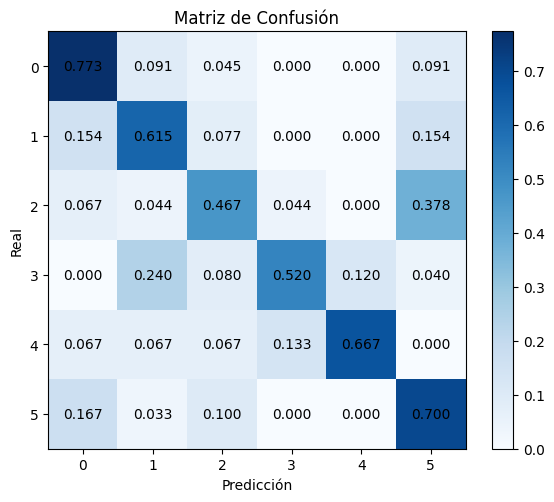

0.6068486419171351


In [432]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, preds, normalize="true")

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.colorbar()

# Agregar valores dentro de cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]:.3f}",
                 ha="center", va="center", color="black")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print(f1_score(y_train, preds, average="macro"))

In [340]:
print(ocde_categories_trad)

['agricultural sciences', 'medical and health sciences', 'natural sciences', 'social sciences', 'Humanities', 'engineering and technologies']


# 4) Exequiel

In [ ]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}


In [442]:
def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [ ]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    # Ajuste por alineación de disciplinas
    alignment = 0
    if pub_text:
        expected = ocde_hierarchy.get(area1, {}).get(sub1, [])
        matches = sum(1 for d in expected if d.lower() in pub_text.lower())
        alignment = matches / len(expected) if expected else 0
    adjusted_sim1 = sim1 * (1 + alignment * 0.1)
    #if adjusted_sim1 < MIN_SIMILARITY_PRIMARY:
    #    return [(None, None)], []  # ninguna clasificación válida

    # Buscar segunda clasificación
    sims_copy = sims.copy()
    sims_copy[best_idx] = -1.0
    second = []
    for idx in np.argsort(sims_copy)[::-1]:
        a, s = ocde_keys[idx]
        sim2 = float(sims_copy[idx])
        if (a != area1 and 
            sim2 >= MIN_SIMILARITY_SECOND and
            sim2 >= adjusted_sim1 * RELATIVE_THRESHOLD):
            # reajustar con alineación
            alignment2 = 0
            if pub_text:
                expected2 = ocde_hierarchy.get(a, {}).get(s, [])
                matches2 = sum(1 for d in expected2 if d.lower() in pub_text.lower())
                alignment2 = matches2 / len(expected2) if expected2 else 0
            sim2 *= (1 + alignment2 * 0.1)
            second = [(a, s)]
            break

    # Devolver lista de clasificaciones: [(area1, sub1), (area2, sub2)?]
    #result = [(area1, sub1)]
    result = area1
    if second:
        result.append(second[0])
    return result

#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Categorías OCDE
ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'humanities', 'engineering and technology']
                                                

original_code= ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales",
                "ciencias sociales",  "humanidades",  "ingeniería y tecnología"]

#Lectura de codigos 
#Reemplazar areas ocde
df = replace_ocde_codes(df, original_code, ocde_categories_trad)


# 5) Clasificar cada publicación
df["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X_train)
]

df["clasificaciones"] = df["clasificaciones"].astype(str).str.lower()

In [487]:
df["clasificaciones"].value_counts()

engineering and technology     47
agricultural sciences          28
social sciences                24
natural sciences               23
medical and health sciences    16
humanities                     12
Name: clasificaciones, dtype: int64

In [488]:
df["Area OCDE"].value_counts()

natural sciences               45
engineering and technology     30
social sciences                25
agricultural sciences          22
humanities                     15
medical and health sciences    13
Name: Area OCDE, dtype: int64

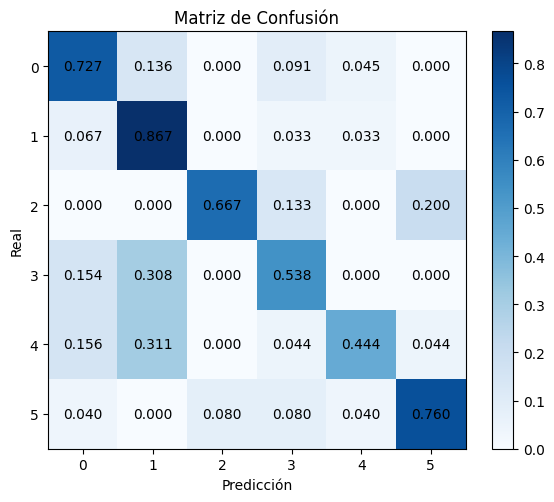

0.6504282558257252


In [490]:
le = LabelEncoder()
y_train = le.fit_transform(df["Area OCDE"])
preds = le.transform(df["clasificaciones"])


from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, preds, normalize="true")

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.colorbar()

# Agregar valores dentro de cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]:.3f}",
                 ha="center", va="center", color="black")

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print(f1_score(y_train, preds, average="macro"))

In [491]:
le.classes_

array(['agricultural sciences', 'engineering and technology',
       'humanities', 'medical and health sciences', 'natural sciences',
       'social sciences'], dtype=object)

# 5) Classificación ordenada SPECTER

### Functions

In [3]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [4]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["Area OCDE"].to_list()
    return X, y, df

In [5]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    # Ajuste por alineación de disciplinas
    alignment = 0
    if pub_text:
        expected = ocde_hierarchy.get(area1, {}).get(sub1, [])
        matches = sum(1 for d in expected if d.lower() in pub_text.lower())
        alignment = matches / len(expected) if expected else 0
    adjusted_sim1 = sim1 * (1 + alignment * 0.1)
    #if adjusted_sim1 < MIN_SIMILARITY_PRIMARY:
    #    return [(None, None)], []  # ninguna clasificación válida

    # Buscar segunda clasificación
    sims_copy = sims.copy()
    sims_copy[best_idx] = -1.0
    second = []
    for idx in np.argsort(sims_copy)[::-1]:
        a, s = ocde_keys[idx]
        sim2 = float(sims_copy[idx])
        if (a != area1 and 
            sim2 >= MIN_SIMILARITY_SECOND and
            sim2 >= adjusted_sim1 * RELATIVE_THRESHOLD):
            # reajustar con alineación
            alignment2 = 0
            if pub_text:
                expected2 = ocde_hierarchy.get(a, {}).get(s, [])
                matches2 = sum(1 for d in expected2 if d.lower() in pub_text.lower())
                alignment2 = matches2 / len(expected2) if expected2 else 0
            sim2 *= (1 + alignment2 * 0.1)
            second = [(a, s)]
            break

    # Devolver lista de clasificaciones: [(area1, sub1), (area2, sub2)?]
    #result = [(area1, sub1)]
    result = area1
    if second:
        result.append(second[0])
    return result

def replace_ocde_codes(df, orig, new):
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE"] = df["Area OCDE"].replace(orig[idx], new[idx])
    return df

### Preprocess

In [10]:
import pandas as pd
import os
import numpy as np
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch


#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
X, _, _ = gen_dataset_select_cols_distance(df, cols = cols)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X, BASE_MODEL, ADAPTER_NAME)

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


### Classify

In [ ]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Categorías OCDE
original_code= ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales",
                "ciencias sociales",  "humanidades",  "ingeniería y tecnología"]

ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'humanities', 'engineering and technology']
                                                
#Lectura de codigos 
#Reemplazar areas ocde
df = replace_ocde_codes(df, original_code, ocde_categories_trad)


# 5) Clasificar cada publicación
df["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X)
]

df["clasificaciones"] = df["clasificaciones"].astype(str).str.lower()

### Evaluate

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, pred):
    
    print("F1-score (macro):", f1_score(y, pred, average="macro"))
    print("Accuracy:", accuracy_score(y, pred))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    print(f1_score(y, preds, average="macro"))
    print(accuracy_score(y, preds))


Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']
F1-score (macro): 0.6358612742232052
Accuracy: 0.6333333333333333


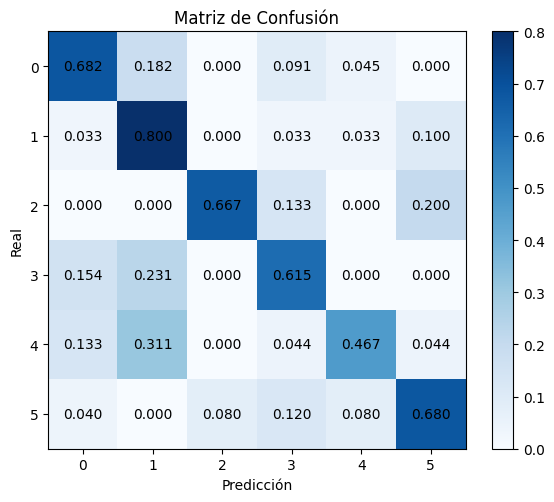

0.6358612742232052
0.6333333333333333


In [27]:
le = LabelEncoder()
y = le.fit_transform(df["Area OCDE"])
preds = le.transform(df["clasificaciones"])

print("Classes name:", le.classes_)
print_metrics(y, preds)

# 5) Classificación ordenada all-mpnet-base-v2

### Functions

In [ ]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [ ]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["Area OCDE"].to_list()
    return X, y, df

In [94]:
from sentence_transformers import SentenceTransformer
import torch
import numpy as np

def encoder_batch_sentence_transformers(model_name, texts, batch_size=8, max_length=512):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SentenceTransformer(model_name, device=device)  # ya queda en GPU si existe

    # encode hace batching automáticamente, pero si quieres controlar batch_size lo pasas como argumento
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        show_progress_bar=True
    )

    return embeddings  # (n_texts, hidden_dim)

In [95]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    # Ajuste por alineación de disciplinas
    alignment = 0
    if pub_text:
        expected = ocde_hierarchy.get(area1, {}).get(sub1, [])
        matches = sum(1 for d in expected if d.lower() in pub_text.lower())
        alignment = matches / len(expected) if expected else 0
    adjusted_sim1 = sim1 * (1 + alignment * 0.1)
    #if adjusted_sim1 < MIN_SIMILARITY_PRIMARY:
    #    return [(None, None)], []  # ninguna clasificación válida

    # Buscar segunda clasificación
    sims_copy = sims.copy()
    sims_copy[best_idx] = -1.0
    second = []
    for idx in np.argsort(sims_copy)[::-1]:
        a, s = ocde_keys[idx]
        sim2 = float(sims_copy[idx])
        if (a != area1 and 
            sim2 >= MIN_SIMILARITY_SECOND and
            sim2 >= adjusted_sim1 * RELATIVE_THRESHOLD):
            # reajustar con alineación
            alignment2 = 0
            if pub_text:
                expected2 = ocde_hierarchy.get(a, {}).get(s, [])
                matches2 = sum(1 for d in expected2 if d.lower() in pub_text.lower())
                alignment2 = matches2 / len(expected2) if expected2 else 0
            sim2 *= (1 + alignment2 * 0.1)
            second = [(a, s)]
            break

    # Devolver lista de clasificaciones: [(area1, sub1), (area2, sub2)?]
    #result = [(area1, sub1)]
    result = area1
    if second:
        result.append(second[0])
    return result

def replace_ocde_codes(df, orig, new):
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE"] = df["Area OCDE"].replace(orig[idx], new[idx])
    return df

### Preprocess

In [96]:
import pandas as pd
import os
import numpy as np
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch


#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
X, _, _ = gen_dataset_select_cols_distance(df, cols = cols)

#Creacion de vectores TFID
model_name="all-mpnet-base-v2"
emb_ocde = encoder_batch_sentence_transformers(model_name, ocde_texts)
emb_pubs = encoder_batch_sentence_transformers(model_name, X)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

### Classify

In [99]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Categorías OCDE
original_code= ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales",
                "ciencias sociales",  "humanidades",  "ingeniería y tecnología"]

ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'humanities', 'engineering and technology']
                                                
#Lectura de codigos 
#Reemplazar areas ocde
df = replace_ocde_codes(df, original_code, ocde_categories_trad)


# 5) Clasificar cada publicación
df["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X)
]

df["clasificaciones"] = df["clasificaciones"].astype(str).str.lower()

### Evaluate

In [102]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, pred):
    
    print("F1-score (macro):", f1_score(y, pred, average="macro"))
    print("Accuracy:", accuracy_score(y, pred))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']
F1-score (macro): 0.635940605823739
Accuracy: 0.6333333333333333


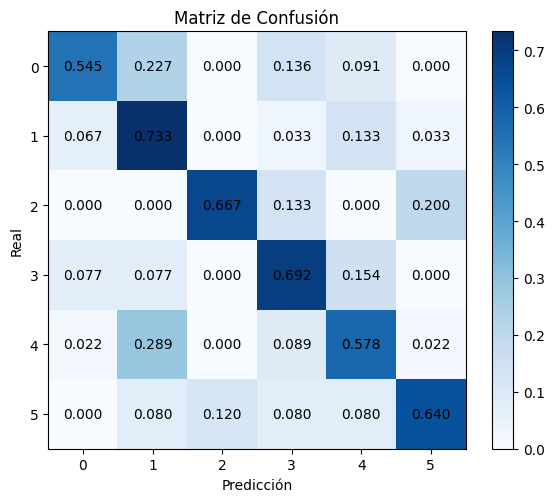

In [103]:
le = LabelEncoder()
y = le.fit_transform(df["Area OCDE"])
preds = le.transform(df["clasificaciones"])

print("Classes name:", le.classes_)
print_metrics(y, preds)

# 6) Subclasificación

### Functions

In [28]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [29]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["Area OCDE"].to_list()
    return X, y, df

In [32]:
def classify_two_stage(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    best_idx = int(np.argmax(sims))
    sim1 = float(sims[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    # Ajuste por alineación de disciplinas
    alignment = 0
    if pub_text:
        expected = ocde_hierarchy.get(area1, {}).get(sub1, [])
        matches = sum(1 for d in expected if d.lower() in pub_text.lower())
        alignment = matches / len(expected) if expected else 0
    adjusted_sim1 = sim1 * (1 + alignment * 0.1)
    #if adjusted_sim1 < MIN_SIMILARITY_PRIMARY:
    #    return [(None, None)], []  # ninguna clasificación válida

    # Buscar segunda clasificación
    sims_copy = sims.copy()
    sims_copy[best_idx] = -1.0
    second = []
    for idx in np.argsort(sims_copy)[::-1]:
        a, s = ocde_keys[idx]
        sim2 = float(sims_copy[idx])
        if (a != area1 and 
            sim2 >= MIN_SIMILARITY_SECOND and
            sim2 >= adjusted_sim1 * RELATIVE_THRESHOLD):
            # reajustar con alineación
            alignment2 = 0
            if pub_text:
                expected2 = ocde_hierarchy.get(a, {}).get(s, [])
                matches2 = sum(1 for d in expected2 if d.lower() in pub_text.lower())
                alignment2 = matches2 / len(expected2) if expected2 else 0
            sim2 *= (1 + alignment2 * 0.1)
            second = [(a, s)]
            break

    # Devolver lista de clasificaciones: [(area1, sub1), (area2, sub2)?]
    #result = [(area1, sub1)]
    result = sub1
    if second:
        result.append(second[0])
    return result

def replace_ocde_codes(df, orig, new):
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE"] = df["Area OCDE"].replace(orig[idx], new[idx])
    return df

### Preprocess

In [31]:
import pandas as pd
import os
import numpy as np
import numpy as np
from sklearn.preprocessing import LabelEncoder


#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
X, _, _ = gen_dataset_select_cols_distance(df, cols = cols)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


### Classify

In [ ]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Categorías OCDE
original_code= ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales",
                "ciencias sociales",  "humanidades",  "ingeniería y tecnología"]

ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'humanities', 'engineering and technology']
                                                
#Lectura de codigos 
#Reemplazar areas ocde
df = replace_ocde_codes(df, original_code, ocde_categories_trad)


# 5) Clasificar cada publicación
df["clasificaciones"] = [
    classify_two_stage(vec, emb_ocde, ocde_keys, ocde_hierarchy, text)
    for vec, text in zip(emb_pubs, X)
]

df["clasificaciones"] = df["clasificaciones"].astype(str).str.lower()

### Evaluate

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, pred):
    
    print("F1-score (macro):", f1_score(y, pred, average="macro"))
    print("Accuracy:", accuracy_score(y, pred))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    print(f1_score(y, preds, average="macro"))
    print(accuracy_score(y, preds))


Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']
F1-score (macro): 0.6358612742232052
Accuracy: 0.6333333333333333


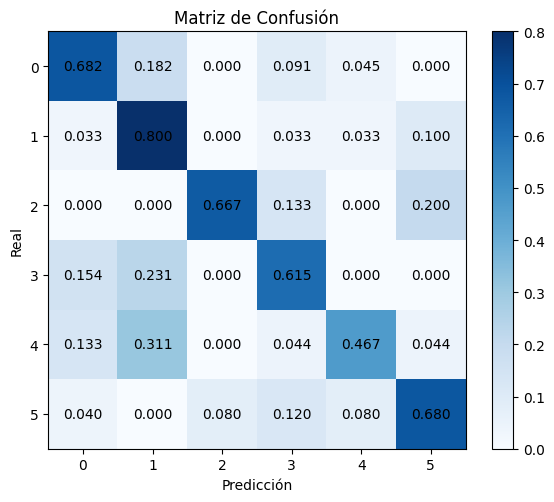

0.6358612742232052
0.6333333333333333


In [ ]:
le = LabelEncoder()
y = le.fit_transform(df["Area OCDE"])
preds = le.transform(df["clasificaciones"])

print("Classes name:", le.classes_)
print_metrics(y, preds)


# 7) Interdiciplinario + OCDE 

In [15]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
path = "/tmp/data"
filepath=os.path.join(path, "data_translated_concat.csv")
df = pd.read_csv(filepath)

In [26]:
#del gen_dataset
from utils.dataset import gen_dataset_select_cols
from models.specter import embed_texts
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "Depto_Persona_trad", "keywords_trad", "Resumen_trad"]
element_names=["Title:", "Department:", "keywords:", "abstract:"]

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset_select_cols(codes_test, df, cols = cols, element_names=element_names)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset_select_cols(codes_train, df, cols = cols)
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 2) Calcular embeddings
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

print(X_train.shape, X_test.shape)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(771, 768) (193, 768)


In [27]:
# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)
#Generar embeddings
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


### Only sim features

In [ ]:
def sim_vectors(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    return sims

#Train
sim_train = []
for vec, text in zip(X_train, df_train["text_for_embedding_translated"]):
    sim_train.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
    
sim_train = np.array(sim_train)
print(sim_train.shape)
#Test
sim_test = []
for vec, text in zip(X_test, df_test["text_for_embedding_translated"]):
    sim_test.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
sim_test = np.array(sim_test)
print(sim_test.shape)

In [72]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, sim_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(771,)
LogisticRegression
Compute sw


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.64, 'std_test_score': 0.02}
RandomForestClassifier: {'mean_test_score': 0.64, 'std_test_score': 0.01}
XGBClassifier: {'mean_test_score': 0.63, 'std_test_score': 0.01}
SVC: {'mean_test_score': 0.64, 'std_test_score': 0.02}


In [73]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, sim_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6735751295336787, 'precision': 0.7033898305084746, 'recall': 0.7477477477477478, 'f1_macro': 0.6618084721720023, 'cm': array([[47, 35],
       [28, 83]]), 'f1_es': 0.6521701194599454, 'f1_en': 0.6923076923076923, 'cm_es': array([[17, 23],
       [16, 59]]), 'cm_en': array([[30, 12],
       [12, 24]])}
RandomForestClassifier
{'accuracy': 0.6373056994818653, 'precision': 0.7029702970297029, 'recall': 0.6396396396396397, 'f1_macro': 0.6337562350900021, 'cm': array([[52, 30],
       [40, 71]]), 'f1_es': 0.6444826306707447, 'f1_en': 0.6196384260900389, 'cm_es': array([[20, 20],
       [21, 54]]), 'cm_en': array([[32, 10],
       [19, 17]])}
XGBClassifier
{'accuracy': 0.6528497409326425, 'precision': 0.6964285714285714, 'recall': 0.7027027027027027, 'f1_macro': 0.6442543123607252, 'cm': array([[48, 34],
       [33, 78]]), 'f1_es': 0.6224687503459883, 'f1_en': 0.6914899054433937, 'cm_es': array([[17, 23],
       [20, 55]]), 'cm_en': array([[31, 11],
       [1

### Only embeddings

In [81]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(771,)
LogisticRegression
Compute sw


/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [1.0, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [10, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbf

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.65, 'std_test_score': 0.01}
RandomForestClassifier: {'mean_test_score': 0.64, 'std_test_score': 0.01}
XGBClassifier: {'mean_test_score': 0.63, 'std_test_score': 0.03}
SVC: {'mean_test_score': 0.65, 'std_test_score': 0.02}


In [82]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6735751295336787, 'precision': 0.7068965517241379, 'recall': 0.7387387387387387, 'f1_macro': 0.6631202726290416, 'cm': array([[48, 34],
       [29, 82]]), 'f1_es': 0.641655965266312, 'f1_en': 0.7038019451812555, 'cm_es': array([[16, 24],
       [16, 59]]), 'cm_en': array([[32, 10],
       [13, 23]])}
RandomForestClassifier
{'accuracy': 0.694300518134715, 'precision': 0.7321428571428571, 'recall': 0.7387387387387387, 'f1_macro': 0.6867314093922805, 'cm': array([[52, 30],
       [29, 82]]), 'f1_es': 0.6700075492312303, 'f1_en': 0.7145299145299145, 'cm_es': array([[18, 22],
       [15, 60]]), 'cm_en': array([[34,  8],
       [14, 22]])}
XGBClassifier
{'accuracy': 0.7046632124352331, 'precision': 0.7368421052631579, 'recall': 0.7567567567567568, 'f1_macro': 0.6963146997929606, 'cm': array([[52, 30],
       [27, 84]]), 'f1_es': 0.69041608228144, 'f1_en': 0.7171990799897776, 'cm_es': array([[20, 20],
       [15, 60]]), 'cm_en': array([[32, 10],
       [12, 2

### All features

In [28]:
def sim_vectors(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    return sims

#Train
sim_train = []
for vec, text in zip(X_train, df_train["text_for_embedding_translated"]):
    sim_train.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
    
sim_train = np.array(sim_train)
print(sim_train.shape)
#Test
sim_test = []
for vec, text in zip(X_test, df_test["text_for_embedding_translated"]):
    sim_test.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
sim_test = np.array(sim_test)
print(sim_test.shape)

(771, 39)
(193, 39)


In [29]:
all_train = np.concatenate((sim_train, X_train), axis=1)
all_test = np.concatenate((sim_test, X_test), axis=1)
print(all_train.shape, all_test.shape)

(771, 807) (193, 807)


In [30]:
from sklearn.preprocessing import minmax_scale
all_train = minmax_scale(all_train, axis=0)
all_test = minmax_scale(all_test, axis=0)

In [31]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, all_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 'l2', 'lbfgs'] before, using random point [10, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.64, 'std_test_score': 0.02}
RandomForestClassifier: {'mean_test_score': 0.65, 'std_test_score': 0.01}
XGBClassifier: {'mean_test_score': 0.64, 'std_test_score': 0.02}
SVC: {'mean_test_score': 0.64, 'std_test_score': 0.02}


In [32]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, all_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6735751295336787, 'precision': 0.6967213114754098, 'recall': 0.7657657657657657, 'f1_macro': 0.6589245140116131, 'cm': array([[45, 37],
       [26, 85]]), 'f1_es': 0.6301295028760565, 'f1_en': 0.7038019451812555, 'cm_es': array([[13, 27],
       [13, 62]]), 'cm_en': array([[32, 10],
       [13, 23]])}
RandomForestClassifier
{'accuracy': 0.6787564766839378, 'precision': 0.7289719626168224, 'recall': 0.7027027027027027, 'f1_macro': 0.6732743556138051, 'cm': array([[53, 29],
       [33, 78]]), 'f1_es': 0.6625237277411189, 'f1_en': 0.6838604086373476, 'cm_es': array([[18, 22],
       [16, 59]]), 'cm_en': array([[35,  7],
       [17, 19]])}
XGBClassifier
{'accuracy': 0.6839378238341969, 'precision': 0.711864406779661, 'recall': 0.7567567567567568, 'f1_macro': 0.6725447111506689, 'cm': array([[48, 34],
       [27, 84]]), 'f1_es': 0.6700075492312303, 'f1_en': 0.6923076923076923, 'cm_es': array([[18, 22],
       [15, 60]]), 'cm_en': array([[30, 12],
       [12

### Sim and softmax

In [83]:
from scipy.special import softmax

def sim_vectors(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    sims = softmax(sims)
    return sims

#Train
sim_train = []
for vec, text in zip(X_train, df_train["text_for_embedding_translated"]):
    sim_train.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
    
sim_train = np.array(sim_train)
print(sim_train.shape)
#Test
sim_test = []
for vec, text in zip(X_test, df_test["text_for_embedding_translated"]):
    sim_test.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
sim_test = np.array(sim_test)
print(sim_test.shape)

(771, 39)
(193, 39)


In [88]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, sim_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(771,)
LogisticRegression
Compute sw


/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [1.0, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 'l2', 'lbfgs'] before, using random point [10, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 'l2', '

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.57, 'std_test_score': 0.04}
RandomForestClassifier: {'mean_test_score': 0.65, 'std_test_score': 0.02}
XGBClassifier: {'mean_test_score': 0.62, 'std_test_score': 0.02}
SVC: {'mean_test_score': 0.61, 'std_test_score': 0.04}


In [89]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, sim_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6062176165803109, 'precision': 0.7011494252873564, 'recall': 0.5495495495495496, 'f1_macro': 0.6059531485063401, 'cm': array([[56, 26],
       [50, 61]]), 'f1_es': 0.5917519181585678, 'f1_en': 0.6400715563506261, 'cm_es': array([[27, 13],
       [35, 40]]), 'cm_en': array([[29, 13],
       [15, 21]])}
RandomForestClassifier
{'accuracy': 0.6476683937823834, 'precision': 0.6837606837606838, 'recall': 0.7207207207207207, 'f1_macro': 0.6356873195647346, 'cm': array([[45, 37],
       [31, 80]]), 'f1_es': 0.6343326896886607, 'f1_en': 0.653444649799248, 'cm_es': array([[16, 24],
       [17, 58]]), 'cm_en': array([[29, 13],
       [14, 22]])}
XGBClassifier
{'accuracy': 0.6217616580310881, 'precision': 0.6637931034482759, 'recall': 0.6936936936936937, 'f1_macro': 0.6096473000304768, 'cm': array([[43, 39],
       [34, 77]]), 'f1_es': 0.6049091573388249, 'f1_en': 0.6414989097915927, 'cm_es': array([[16, 24],
       [21, 54]]), 'cm_en': array([[27, 15],
       [13

### Softmax + all features

In [18]:
from scipy.special import softmax

def sim_vectors(pub_vec, ocde_vecs, ocde_keys, ocde_hierarchy, pub_text=""):
    sims = ocde_vecs @ pub_vec
    sims = softmax(sims)
    return sims

#Train
sim_train = []
for vec, text in zip(X_train, df_train["text_for_embedding_translated"]):
    sim_train.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
    
sim_train = np.array(sim_train)
print(sim_train.shape)
#Test
sim_test = []
for vec, text in zip(X_test, df_test["text_for_embedding_translated"]):
    sim_test.append(sim_vectors(vec, emb_ocde, ocde_keys, ocde_hierarchy, text))
sim_test = np.array(sim_test)
print(sim_test.shape)

all_train = np.concatenate((sim_train, X_train), axis=1)
all_test = np.concatenate((sim_test, X_test), axis=1)
print(all_train.shape, all_test.shape)

(771, 39)
(193, 39)
(771, 807) (193, 807)


In [23]:
from sklearn.preprocessing import minmax_scale
all_train = minmax_scale(all_train, axis=0)
all_test = minmax_scale(all_test, axis=0)

In [24]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, all_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(771,)
LogisticRegression
Compute sw


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.64, 'std_test_score': 0.01}
RandomForestClassifier: {'mean_test_score': 0.64, 'std_test_score': 0.02}
XGBClassifier: {'mean_test_score': 0.63, 'std_test_score': 0.02}
SVC: {'mean_test_score': 0.65, 'std_test_score': 0.02}


In [25]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, all_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6735751295336787, 'precision': 0.6935483870967742, 'recall': 0.7747747747747747, 'f1_macro': 0.6573481752853318, 'cm': array([[44, 38],
       [25, 86]]), 'f1_es': 0.6254583551597693, 'f1_en': 0.7038019451812555, 'cm_es': array([[12, 28],
       [12, 63]]), 'cm_en': array([[32, 10],
       [13, 23]])}
RandomForestClassifier
{'accuracy': 0.6839378238341969, 'precision': 0.7314814814814815, 'recall': 0.7117117117117117, 'f1_macro': 0.6780958630683838, 'cm': array([[53, 29],
       [32, 79]]), 'f1_es': 0.6651609260304912, 'f1_en': 0.7005917159763313, 'cm_es': array([[19, 21],
       [17, 58]]), 'cm_en': array([[34,  8],
       [15, 21]])}
XGBClassifier
{'accuracy': 0.7046632124352331, 'precision': 0.7410714285714286, 'recall': 0.7477477477477478, 'f1_macro': 0.6973506836501693, 'cm': array([[53, 29],
       [28, 83]]), 'f1_es': 0.7004071443430713, 'f1_en': 0.7038019451812555, 'cm_es': array([[21, 19],
       [15, 60]]), 'cm_en': array([[32, 10],
       [1

# 8) Classificación p(a)*p(a|b)

### Functions

In [33]:
ocde_hierarchy = {
    "Natural Sciences": {
        "Mathematics": [
            "Pure Mathematics",
            "Applied Mathematics",
            "Statistics and Probability"
        ],
        "Computer and Information Sciences": [
            "Computer Science",
            "Information Science",
            "Bioinformatics"
        ],
        "Physical Sciences": [
            "Atomic, Molecular and Chemical Physics",
            "Condensed Matter Physics",
            "Particle Physics and Field Physics",
            "Nuclear Physics",
            "Plasma and Fluid Physics",
            "Optics",
            "Acoustics",
            "Astronomy",
            "Other Physics Specialties"
        ],
        "Chemical Sciences": [
            "Organic Chemistry",
            "Inorganic and Nuclear Chemistry",
            "Physical Chemistry",
            "Polymer Science",
            "Electrochemistry",
            "Colloid Chemistry",
            "Analytical Chemistry"
        ],
        "Earth and Environmental Sciences": [
            "Multidisciplinary Geosciences",
            "Mineralogy",
            "Paleontology",
            "Geochemistry and Geophysics",
            "Physical Geography",
            "Geology",
            "Volcanology",
            "Environmental Sciences",
            "Meteorology and Atmospheric Sciences",
            "Climate Research",
            "Oceanography, Hydrology and Water Resources"
        ],
        "Biological Sciences": [
            "Cell Biology and Microbiology",
            "Virology",
            "Biochemistry and Molecular Biology",
            "Biochemical Research Methods",
            "Mycology",
            "Biophysics",
            "Genetics and Heredity",
            "Reproductive Biology",
            "Developmental Biology",
            "Plant Sciences and Botany",
            "Zoology, Ornithology, Entomology and Behavioral Biology",
            "Marine Biology, Freshwater Biology and Limnology",
            "Ecology",
            "Theoretical, Mathematical and Thermal Biology; Cryobiology; Biological Rhythms; Evolutionary Biology"
        ]
    },
    "Engineering and Technology": {
        "Civil Engineering": [
            "Civil Engineering",
            "Architectural Engineering",
            "Construction Engineering",
            "Structural and Municipal Engineering",
            "Transportation Engineering"
        ],
        "Electrical, Electronic and Computer Engineering": [
            "Electrical and Electronic Engineering",
            "Robotics and Automatic Control",
            "Automation and Control Systems",
            "Systems and Communications Engineering",
            "Telecommunications",
            "Hardware and Computer Architecture"
        ],
        "Mechanical Engineering": [
            "Mechanical Engineering",
            "Applied Mechanics",
            "Thermodynamics",
            "Aerospace Engineering",
            "Nuclear Energy Engineering",
            "Audio Engineering and Reliability Analysis"
        ],
        "Chemical Engineering": [
            "Chemical Engineering",
            "Process Engineering"
        ],
        "Materials Engineering": [
            "Materials Engineering",
            "Ceramics",
            "Coatings and Films",
            "Composites",
            "Paper and Wood Engineering",
            "Textiles",
            "Synthetic Dyes, Colors and Fibers"
        ],
        "Medical Engineering": [
            "Medical Engineering",
            "Medical Laboratory Technology (Sample Analysis, Diagnostic Technologies)"
        ],
        "Environmental Engineering": [
            "Environmental and Geological Engineering",
            "Geotechnical Engineering",
            "Petroleum Engineering (Fuels, Oils); Energy and Fuels",
            "Remote Sensing",
            "Mining and Mineral Processing Engineering",
            "Marine and Naval Engineering",
            "Oceanographic Engineering"
        ],
        "Environmental Biotechnology": [
            "Environmental Biotechnology",
            "Bioremediation and Diagnostic Biotechnologies for Environmental Management",
            "Ethics in Environmental Biotechnology"
        ],
        "Industrial Biotechnology": [
            "Industrial Biotechnology",
            "Bioprocessing Technologies, Biocatalysis and Fermentation",
            "Bioproducts"
        ],
        "Nanotechnology": [
            "Nanomaterials",
            "Nanoprocesses"
        ],
        "Other Engineering and Technologies": [
            "Food and Beverage Engineering",
            "Other Engineering and Technologies",
            "Production Engineering",
            "Industrial Engineering"
        ]
    },
    "Medical and Health Sciences": {
        "Basic Medicine": [
            "Anatomy and Morphology",
            "Human Genetics",
            "Immunology",
            "Neurosciences",
            "Pharmacology and Pharmacy",
            "Medicinal Chemistry",
            "Toxicology",
            "Physiology",
            "Pathology"
        ],
        "Clinical Medicine": [
            "Andrology",
            "Obstetrics and Gynecology",
            "Pediatrics",
            "Cardiology and the Cardiovascular System",
            "Peripheral Vascular Disease",
            "Hematology",
            "Respiratory System",
            "Critical and Emergency Care",
            "Anesthesiology",
            "Orthopedics",
            "Surgery",
            "Radiology, Nuclear Medicine and Medical Imaging",
            "Transplantation",
            "Dentistry, Oral Surgery and Oral Medicine",
            "Dermatology and Venereal Diseases",
            "Allergy",
            "Rheumatology",
            "Endocrinology and Metabolism",
            "Gastroenterology and Hepatology",
            "Urology and Nephrology",
            "Oncology",
            "Ophthalmology",
            "Otorhinolaryngology",
            "Psychiatry",
            "Clinical Neurology",
            "Geriatrics and Gerontology",
            "General and Internal Medicine",
            "Other Clinical Medicine Topics",
            "Holistic and Complementary Medicine"
        ],
        "Health Sciences": [
            "Health Care and Services Sciences (Hospital Administration, Financing)",
            "Health Policy and Health Services",
            "Nursing",
            "Nutrition and Dietetics",
            "Public and Environmental Health",
            "Tropical Medicine",
            "Parasitology",
            "Infectious Diseases",
            "Epidemiology",
            "Occupational Health",
            "Sports Sciences and Physical Fitness",
            "Socio-Biomedical Sciences",
            "Bioethics",
            "Substance Abuse"
        ],
        "Medical Biotechnology": [
            "Health-Related Biotechnology",
            "Cell, Tissue and Organ Engineering Technologies",
            "Genetic and Protein Technologies",
            "Biomaterials",
            "Ethics in Medical Biotechnology"
        ],
        "Other Medical Sciences": [
            "Forensic Science",
            "Other Medical Sciences",
            "Speech and Language Therapy"
        ]
    },
    "Agricultural Sciences": {
        "Agriculture, Forestry and Fisheries": [
            "Agriculture",
            "Forestry",
            "Fisheries",
            "Soil Science",
            "Horticulture and Viticulture",
            "Agronomy",
            "Plant Protection and Nutrition"
        ],
        "Animal and Dairy Sciences": [
            "Animal Science and Dairy Science",
            "Animal Husbandry",
            "Animal Breeding and Pet Science"
        ],
        "Veterinary Science": [
            "Veterinary Science"
        ],
        "Agricultural Biotechnology": [
            "Agricultural and Food Biotechnology",
            "Genetic Modification Technology",
            "Ethics in Agricultural Biotechnology"
        ]
    },
    "Social Sciences": {
        "Psychology": [
            "Psychology (Human–Machine Relations)",
            "Psychology (Therapies for Learning, Speech, Visual and Other Disabilities)"
        ],
        "Economics and Business": [
            "Economics",
            "Econometrics",
            "Industrial Relations",
            "Business and Administration"
        ],
        "Education Sciences": [
            "General Education (Training, Pedagogy)",
            "Special Education (Gifted and Learning Difficulties)"
        ],
        "Sociology": [
            "Sociology",
            "Demography",
            "Anthropology",
            "Ethnology",
            "Social Issues"
        ],
        "Law": [
            "Law",
            "Criminal Law",
            "Criminology"
        ],
        "Political Science": [
            "Political Science",
            "Public Administration",
            "Organizational Theory"
        ],
        "Social and Economic Geography": [
            "Environmental Sciences",
            "Economic and Cultural Geography",
            "Urban Studies",
            "Transportation Planning and Social Aspects"
        ],
        "Journalism and Communications": [
            "Journalism",
            "Information Sciences",
            "Library Science",
            "Media and Socio-cultural Communication"
        ],
        "Other Social Sciences": [
            "Interdisciplinary Studies"
        ]
    },
    "Humanities": {
        "History and Archaeology": [
            "History",
            "Archaeology"
        ],
        "Languages and Literature": [
            "General Language Studies",
            "Specific Languages",
            "General Literature Studies",
            "Literary Theory",
            "Specific Literatures",
            "Linguistics"
        ],
        "Philosophy, Ethics and Religion": [
            "Philosophy",
            "History and Philosophy of Science and Technology",
            "Ethics",
            "Theology",
            "Religious Studies"
        ],
        "Arts and Communication": [
            "Art",
            "Art History",
            "Architectural Design",
            "Performing Arts (Musicology, Theatre Studies, Dramaturgy)",
            "Folklore Studies",
            "Film, Radio and Television Studies",
            "Music",
            "Architecture and Urban Planning",
            "Industrial and Other Designs"
        ]
    }
}

discipline_code = {
    "Mathematics": 15003,
    "Computer and Information Sciences": 15026,
    "Physical Sciences": 15049,
    "Chemical Sciences": 15068,
    "Earth and Environmental Sciences": 15092,
    "Biological Sciences": 15116,
    "Other Natural Sciences": 15118,
    "Civil Engineering": 15125,
    "Electrical, Electronic and Computer Engineering": 15146,
    "Mechanical Engineering": 15166,
    "Chemical Engineering": 15182,
    "Materials Engineering": 15207,
    "Medical Engineering": 15222,
    "Environmental Engineering": 15247,
    "Environmental Biotechnology": 15263,
    "Industrial Biotechnology": 15283,
    "Nanotechnology": 15302,
    "Other Engineering and Technologies": 15324,
    "Basic Medicine": 15349,
    "Clinical Medicine": 15389,
    "Health Sciences": 15414,
    "Medical Biotechnology": 15425,
    "Other Medical Sciences": 15443,
    "Agriculture, Forestry and Fisheries": 15467,
    "Animal and Dairy Sciences": 15483,
    "Veterinary Science": 15505,
    "Agricultural Biotechnology": 15504,
    "Other Agricultural Sciences": 15512,
    "Psychology": 15522,
    "Economics and Business": 15544,
    "Education Sciences": 15563,
    "Sociology": 15585,
    "Law": 15603,
    "Political Science": 15623,
    "Social and Economic Geography": 15644,
    "Journalism and Communications": 15664,
    "Other Social Sciences": 15682,
    "History and Archaeology": 15702,
    "Languages and Literature": 15717,
    "Philosophy, Ethics and Religion": 15725,
    "Arts and Communication": 15749,
    "Other Humanities": 15761
}

In [ ]:
from preprocess.translate import gen_text_for_embedding, final_clean
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

def build_ocde_texts(ocde_dict):
    keys, texts = [], []
    for area, subs in ocde_dict.items():
        for sub, discs in subs.items():
            keys.append((area, sub))
            area_ctx = f"Field of research: {area}. "
            sub_ctx  = f"Specific research domain: {sub}. "
            disc_ctx = f"Related disciplines and topics: {'; '.join(discs)}"
            texts.append(area_ctx + sub_ctx + disc_ctx)
    return keys, texts

def embed_texts(texts, BASE_MODEL, ADAPTER_NAME, batch_size=32, device='cpu'):
    #Parameters
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model = AutoAdapterModel.from_pretrained(BASE_MODEL, trust_remote_code=True)
    model.load_adapter(ADAPTER_NAME, source="hf", set_active=True, load_as="classification")
    model.to(device)
    model.eval()
    print("Modelo SPECTER2 cargado correctamente.")
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch,
                            padding=True,
                            truncation=True,
                            return_tensors="pt",
                            max_length=512).to(device)
        with torch.no_grad():
            out = model(**encoded)
            embs = out.last_hidden_state[:, 0, :]
        embs = torch.nn.functional.normalize(embs, p=2, dim=1)
        embeddings.append(embs.cpu().numpy())
    return np.vstack(embeddings)

def gen_dataset_select_cols_distance(df, cols, element_names=None):
    #Generación de datasets
    for col in cols:
        df[col] = df[col].apply(final_clean)

    df=gen_text_for_embedding(df, cols, element_names=element_names)
    X = df["text_for_embedding_translated"].to_list()
    y = df["Area OCDE"].to_list()
    return X, y, df

In [35]:
def replace_ocde_codes(df, orig, new):
    n_codes = len(orig)
    for idx in range(n_codes):
        df["Area OCDE"] = df["Area OCDE"].replace(orig[idx], new[idx])
    return df

In [90]:
def build_ocde_texts_general(ocde_dict):
    all_texts = []
    for area, subs in ocde_dict.items():
        texts = []
        area_ctx = f"Field of research: {area}. "
        texts.append(area_ctx)
        for sub, discs in subs.items():
            sub_ctx  = f"{sub}. "
            disc_ctx = f"{'; '.join(discs)}"
            texts.append(sub_ctx + disc_ctx)
        all_texts.append(texts)
    #Unir todos los textos en un string
    all_texts = [" ".join(text) for text in all_texts]
    return all_texts

def classify_two_stage(pub_vec, ocde_vecs, ocde_vecs_general, ocde_keys, ocde_hierarchy, pub_text=""):
    #Sims
    general_sims = ocde_vecs_general @ pub_vec
    sub_sims = ocde_vecs @ pub_vec 
    #probability 
    p_general = softmax(general_sims)
    p_sub = softmax(sub_sims)
    #Duplicate the general probs to match the shape of sub sims
    p_general_expanded = np.repeat(p_general, [len(subs) for subs in ocde_hierarchy.values()])
    #Combined score
    combined_scores = p_general_expanded * p_sub
    
    best_idx = int(np.argmax(combined_scores))
    sim1 = float(combined_scores[best_idx])
    area1, sub1 = ocde_keys[best_idx]
    
    result = area1
    return result


### Preprocess

In [81]:
import pandas as pd
import os
import numpy as np
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch


#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

# 2) Preparar textos OCDE y embeddings de publicaciones
ocde_keys, ocde_texts = build_ocde_texts(ocde_hierarchy)

#Lectura de codigos 
#Columnas a seleccionar para clasificación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
X, _, _ = gen_dataset_select_cols_distance(df, cols = cols)

#Creacion de vectores TFID
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
emb_ocde = embed_texts(ocde_texts, BASE_MODEL, ADAPTER_NAME)
emb_pubs = embed_texts(X, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


In [82]:
ocde_texts_general = build_ocde_texts_general(ocde_hierarchy)
ocde_vecs_general = embed_texts(ocde_texts_general, BASE_MODEL, ADAPTER_NAME)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


### Classify

In [91]:
# ————————————————————————————————————————————————————————————————
# Parámetros generales
BATCH_SIZE = 16
MIN_SIMILARITY_PRIMARY = 0.80
RELATIVE_THRESHOLD = 0.90
MIN_SIMILARITY_SECOND = 0.85
DISCIPLINE_ALIGNMENT_THRESHOLD = 0.1
# ————————————————————————————————————————————————————————————————

#Lectura de data
path = "/tmp/distance/data/"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Categorías OCDE
original_code= ["ciencias agrícolas", "ciencias médicas y de salud", "ciencias naturales",
                "ciencias sociales",  "humanidades",  "ingeniería y tecnología"]

ocde_categories_trad = ["agricultural sciences", "medical and health sciences", "natural sciences",
                         "social sciences", 'humanities', 'engineering and technology']
                                                
#Lectura de codigos 
#Reemplazar areas ocde
df = replace_ocde_codes(df, original_code, ocde_categories_trad)


# 5) Clasificar cada publicación
preds = []
for vec, text in zip(emb_pubs, X):
    preds.append(classify_two_stage(vec, emb_ocde, ocde_vecs_general, ocde_keys, ocde_hierarchy, text))

df["clasificaciones"] = preds

df["clasificaciones"] = df["clasificaciones"].astype(str).str.lower()

### Evaluate

In [92]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

def print_metrics(y, pred):
    
    print("F1-score (macro):", f1_score(y, pred, average="macro"))
    print("Accuracy:", accuracy_score(y, pred))
    
    #Confusion matrix
    cm = confusion_matrix(y, preds, normalize="true")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Matriz de Confusión")
    plt.colorbar()

    # Agregar valores dentro de cada celda
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.3f}",
                    ha="center", va="center", color="black")

    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    print(f1_score(y, preds, average="macro"))
    print(accuracy_score(y, preds))


Classes name: ['agricultural sciences' 'engineering and technology' 'humanities'
 'medical and health sciences' 'natural sciences' 'social sciences']
F1-score (macro): 0.6183702378095616
Accuracy: 0.62


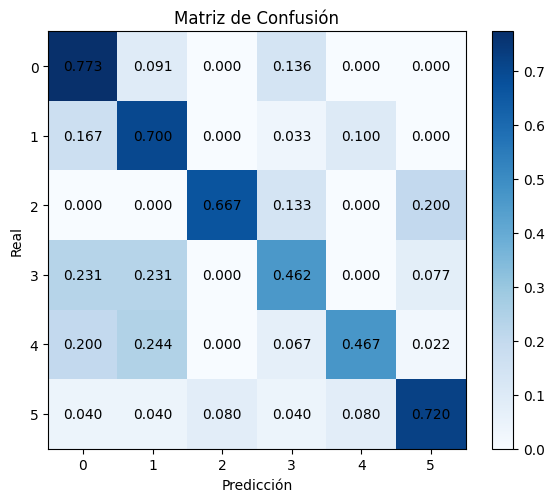

0.6183702378095616
0.62


In [93]:
le = LabelEncoder()
y = le.fit_transform(df["Area OCDE"])
preds = le.transform(df["clasificaciones"])

print("Classes name:", le.classes_)
print_metrics(y, preds)